# Phase 3 — Learner Data Exploratory Data Analysis (EDA)
## Video Intelligence Platform ML Engineering Pipeline

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the **NEW synthetic learner cohort (Users 3–103)** extracted from `backend/video_intelligence.db`.

### Key Business & ML Objectives:
1. Understand the distribution, sequence length, and difficulty levels across learner quiz attempts.
2. Analyze per-learner score trajectories, overall learning slopes, and attempt-to-attempt score volatility.
3. Establish objective, statistically defensible criteria to identify **highly inconsistent / high-variance learner trajectories**.
4. Separate normal learning progressions from chaotic outlier cohorts to build a clean dataset (`ml/data/processed/clean_learner_dataset.csv`) for predictive modeling.

> **Data Safety Guarantee**: Production Users 1 and 2 are strictly excluded from this ML dataset. Excluded outlier learners remain intact in the SQLite database and are excluded **ONLY** from the machine learning training dataset.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication quality styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

# Add project root to sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "ml/data/raw/new_learner_dataset.csv")
METADATA_PATH = os.path.join(PROJECT_ROOT, "ml/data/raw/dataset_metadata.json")

print(f"Loading raw dataset from: {RAW_DATA_PATH}")
df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw['created_at'] = pd.to_datetime(df_raw['created_at'])
print(f"Loaded {len(df_raw)} quiz attempts across {df_raw['user_id'].nunique()} unique learners.")


Loading raw dataset from: /Users/akarshanrasyal/Documents/Projects/video-intelligence-platform/ml/data/raw/new_learner_dataset.csv
Loaded 788 quiz attempts across 101 unique learners.


## 1. Dataset Overview & Cohort Structure

Let's inspect the first 10 rows, data types, missing values, and high-level summary statistics of the raw dataset.


In [2]:
print("--- Dataset Head ---")
print(df_raw.head(10))

print("\n--- Dataset Info ---")
print(df_raw.info())

print("\n--- Dataset Descriptive Statistics ---")
print(df_raw[['score', 'total_questions', 'percentage']].describe())


--- Dataset Head ---
   attempt_id  user_id  attempt_order_by_user  score  total_questions  \
0         734        3                      1     26               40   
1         735        3                      2     19               30   
2         736        3                      3     12               20   
3         737        3                      4     19               30   
4         738        3                      5     19               25   
5         739        3                      6     36               50   
6         740        4                      1     11               20   
7         741        4                      2     23               40   
8         742        4                      3     20               30   
9         743        4                      4     29               40   

   percentage difficulty  video_count  video_ids                 created_at  \
0       65.00       Easy            1         10 2026-04-02 12:14:09.062035   
1       63.33    

## 2. Key Metrics & Categorical Proportions

We examine:
- Total unique learners
- Total attempt count
- Distribution of attempts per learner
- Difficulty distribution (Easy, Medium, Hard) using a Donut Chart for true categorical proportions.


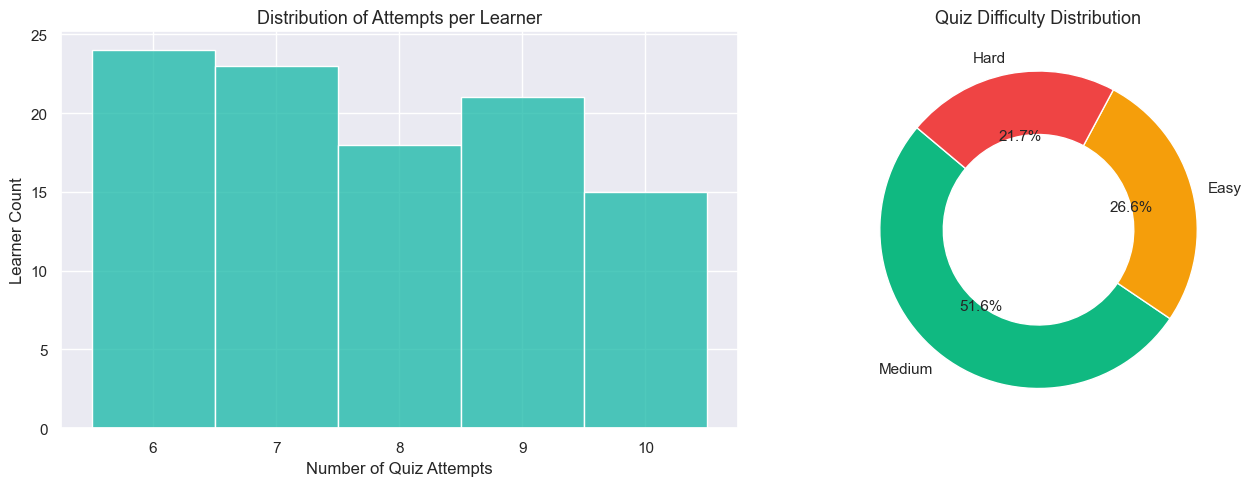

Total Learners: 101
Total Quiz Attempts: 788
Min attempts per learner: 6, Max attempts: 10


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Attempts per Learner (Bar / Histogram)
attempts_per_user = df_raw.groupby('user_id').size()
sns.histplot(attempts_per_user, discrete=True, color='#14b8a6', ax=axes[0])
axes[0].set_title('Distribution of Attempts per Learner')
axes[0].set_xlabel('Number of Quiz Attempts')
axes[0].set_ylabel('Learner Count')

# 2. Difficulty Distribution (Donut Chart - Appropriate for categorical proportions)
diff_counts = df_raw['difficulty'].value_counts()
colors = ['#10b981', '#f59e0b', '#ef4444']
axes[1].pie(diff_counts, labels=diff_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title('Quiz Difficulty Distribution')

plt.tight_layout()
plt.show()

print(f"Total Learners: {df_raw['user_id'].nunique()}")
print(f"Total Quiz Attempts: {len(df_raw)}")
print(f"Min attempts per learner: {attempts_per_user.min()}, Max attempts: {attempts_per_user.max()}")


## 3. Score & Percentage Performance Distribution

Let's plot the overall percentage distribution and difficulty-wise performance boxplots.


/var/folders/93/5zbl3sg10tb5pdk51l5jmqrw0000gn/T/ipykernel_40522/3710364364.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='difficulty', y='percentage', palette=['#10b981', '#f59e0b', '#ef4444'], ax=axes[1])


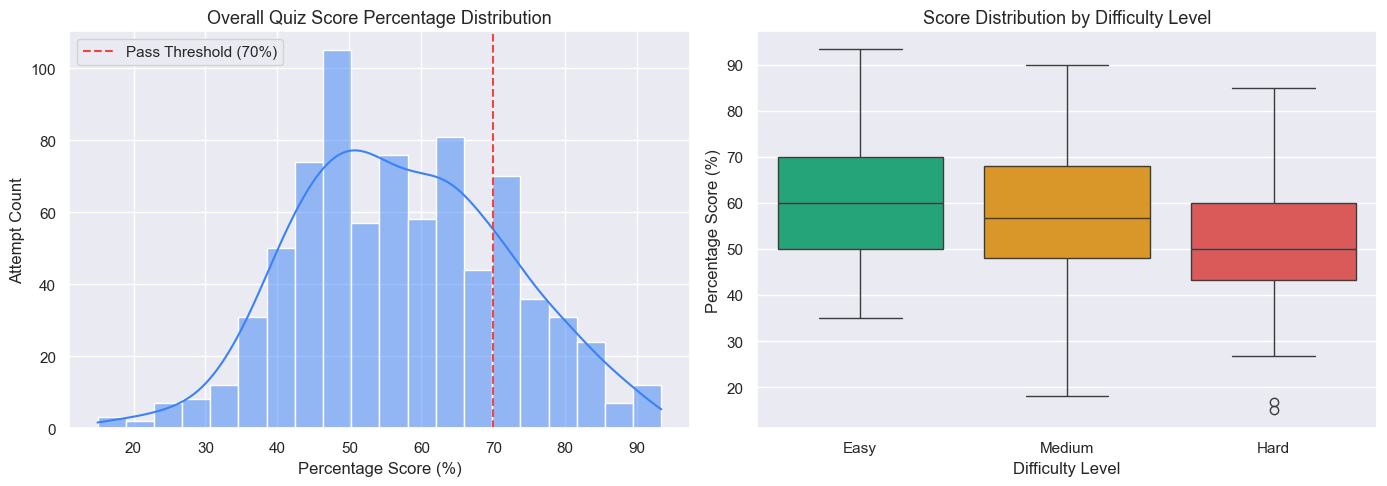

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score Percentage Histogram & KDE
sns.histplot(df_raw['percentage'], kde=True, bins=20, color='#3b82f6', ax=axes[0])
axes[0].axvline(70, color='#ef4444', linestyle='--', label='Pass Threshold (70%)')
axes[0].set_title('Overall Quiz Score Percentage Distribution')
axes[0].set_xlabel('Percentage Score (%)')
axes[0].set_ylabel('Attempt Count')
axes[0].legend()

# Performance by Difficulty Boxplot
sns.boxplot(data=df_raw, x='difficulty', y='percentage', palette=['#10b981', '#f59e0b', '#ef4444'], ax=axes[1])
axes[1].set_title('Score Distribution by Difficulty Level')
axes[1].set_xlabel('Difficulty Level')
axes[1].set_ylabel('Percentage Score (%)')

plt.tight_layout()
plt.show()


## 4. Attempts Timeline Analysis

Let's examine how attempts are distributed chronologically over time across the cohort.


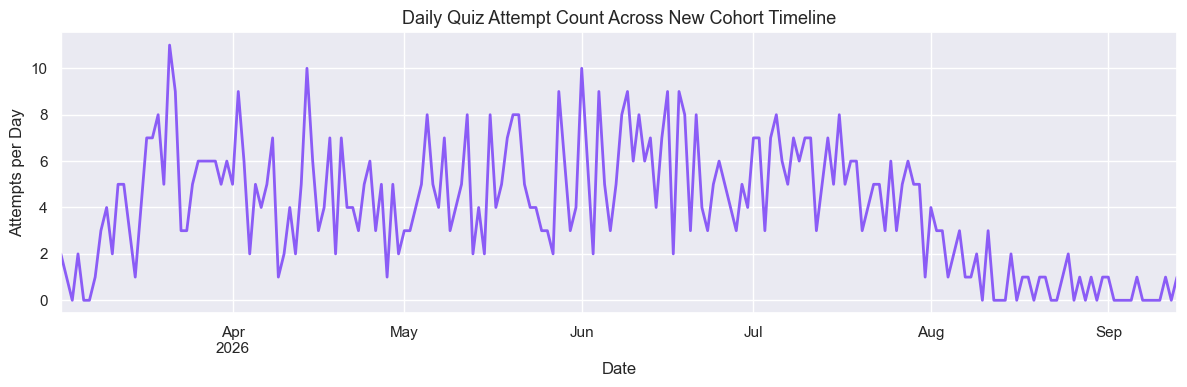

In [5]:
plt.figure(figsize=(12, 4))
df_daily = df_raw.set_index('created_at').resample('D').size()
df_daily.plot(color='#8b5cf6', linewidth=2)
plt.title('Daily Quiz Attempt Count Across New Cohort Timeline')
plt.xlabel('Date')
plt.ylabel('Attempts per Day')
plt.tight_layout()
plt.show()


## 5. Per-Learner & Mean Trajectory Analysis

We analyze:
- Individual score trajectories across consecutive attempts
- Mean cohort learning trajectory from Attempt 1 to Attempt 10


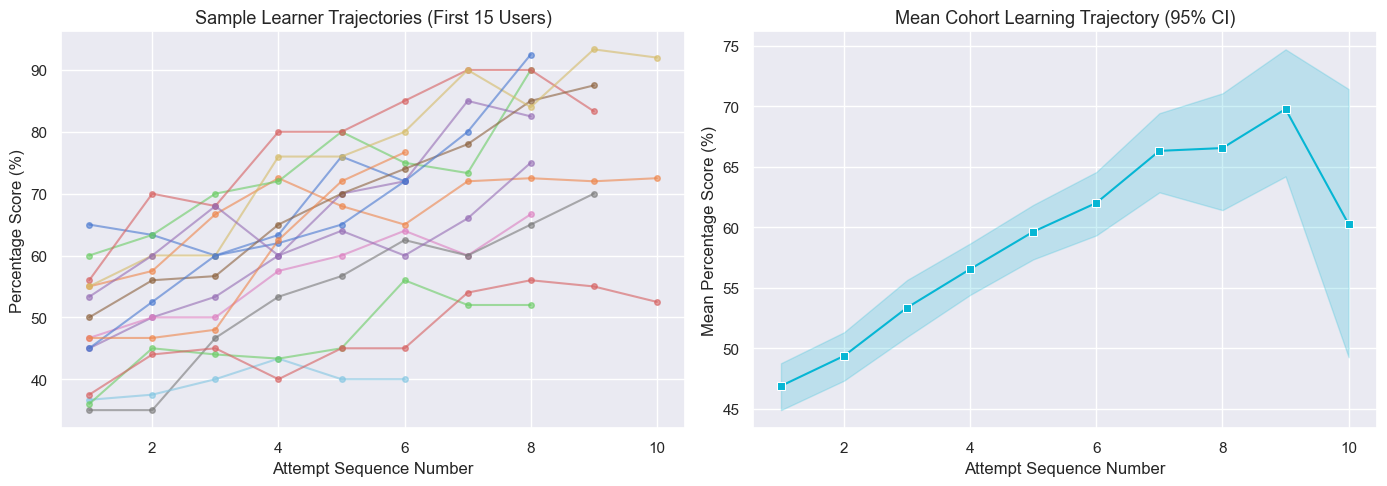

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample 15 Individual Learner Trajectories
sample_users = df_raw['user_id'].unique()[:15]
for uid in sample_users:
    u_data = df_raw[df_raw['user_id'] == uid].sort_values('attempt_order_by_user')
    axes[0].plot(u_data['attempt_order_by_user'], u_data['percentage'], alpha=0.6, marker='o', markersize=4)

axes[0].set_title('Sample Learner Trajectories (First 15 Users)')
axes[0].set_xlabel('Attempt Sequence Number')
axes[0].set_ylabel('Percentage Score (%)')

# Mean Cohort Trajectory with Confidence Interval
sns.lineplot(data=df_raw, x='attempt_order_by_user', y='percentage', color='#06b6d4', marker='s', markersize=6, errorbar=('ci', 95), ax=axes[1])
axes[1].set_title('Mean Cohort Learning Trajectory (95% CI)')
axes[1].set_xlabel('Attempt Sequence Number')
axes[1].set_ylabel('Mean Percentage Score (%)')

plt.tight_layout()
plt.show()


## 6. Learner-Level Behavioral Consistency Metrics

To detect inconsistent trajectories objectively, we compute for each learner:
1. `std_score`: Score standard deviation
2. `slope`: OLS linear trend slope of percentage vs attempt sequence
3. `attempt_score_corr`: Correlation between attempt sequence and percentage score
4. `avg_abs_delta`: Average absolute change between consecutive attempt scores
5. `extreme_reversals_35pct`: Number of consecutive attempt score jumps or drops $\ge 35\%$


In [7]:
from ml.src.run_eda import compute_learner_metrics

df_learner_stats = compute_learner_metrics(df_raw)

print("--- Learner Trajectory Metrics Summary ---")
print(df_learner_stats[['std_score', 'slope', 'attempt_score_corr', 'avg_abs_delta', 'extreme_reversals_35pct']].describe())


--- Learner Trajectory Metrics Summary ---
        std_score       slope  attempt_score_corr  avg_abs_delta  \
count  101.000000  101.000000          101.000000     101.000000   
mean    10.060495    3.041554            0.772554       6.521782   
std      4.426305    2.208004            0.359963       5.326505   
min      2.340000   -5.843000           -0.971000       2.000000   
25%      6.750000    2.057000            0.802000       4.330000   
50%      9.370000    3.282000            0.912000       5.020000   
75%     11.750000    4.250000            0.951000       6.300000   
max     24.520000    7.762000            0.995000      34.000000   

       extreme_reversals_35pct  
count               101.000000  
mean                  0.178218  
std                   0.740217  
min                   0.000000  
25%                   0.000000  
50%                   0.000000  
75%                   0.000000  
max                   4.000000  


## 7. Outlier Learner Detection & Cohort Segmentation

### Objective Exclusion Criteria:
A learner trajectory is classified as an **inconsistent outlier** if:
- **Score Volatility**: `std_score >= 17.5%`
- **Attempt Volatility**: `avg_abs_delta >= 20.0%` OR `extreme_reversals_35pct >= 2`
- **Directional Instability**: `attempt_score_corr < 0.35` (lacks positive learning progress)

> **Important**: Low-performing learners with consistent score patterns are **KEPT**. Only chaotic, high-variance learners are excluded.


In [8]:
from ml.src.run_eda import identify_outlier_learners

df_clean_stats, df_excluded, summary_meta = identify_outlier_learners(df_learner_stats)

print(f"Total Learners Analyzed: {summary_meta['total_learners_analyzed']}")
print(f"Excluded Outlier Learners: {summary_meta['total_learners_excluded']} (User IDs: {summary_meta['excluded_user_ids']})")
print(f"Retained Clean Learners: {summary_meta['total_learners_retained']}")

print("\n--- Excluded Outlier Learner Details ---")
print(df_excluded)


Total Learners Analyzed: 101
Excluded Outlier Learners: 6 (User IDs: [94, 95, 96, 101, 102, 103])
Retained Clean Learners: 95

--- Excluded Outlier Learner Details ---
   user_id                                             reason  \
0       94  High-variance chaotic trajectory: score std=22...   
1       95  High-variance chaotic trajectory: score std=19...   
2       96  High-variance chaotic trajectory: score std=23...   
3      101  High-variance chaotic trajectory: score std=19...   
4      102  High-variance chaotic trajectory: score std=20...   
5      103  High-variance chaotic trajectory: score std=24...   

                          metrics_used_for_exclusion  
0  std_score=22.76, avg_abs_delta=27.59, extreme_...  
1  std_score=19.74, avg_abs_delta=27.18, extreme_...  
2  std_score=23.69, avg_abs_delta=34.0, extreme_r...  
3  std_score=19.96, avg_abs_delta=21.0, extreme_r...  
4  std_score=20.01, avg_abs_delta=18.69, extreme_...  
5  std_score=24.52, avg_abs_delta=22.56, extre

## 8. Normal Learning vs. Inconsistent Outlier Trajectories

Visual comparison demonstrating the stark behavioral contrast between retained clean learners and excluded high-variance learners.


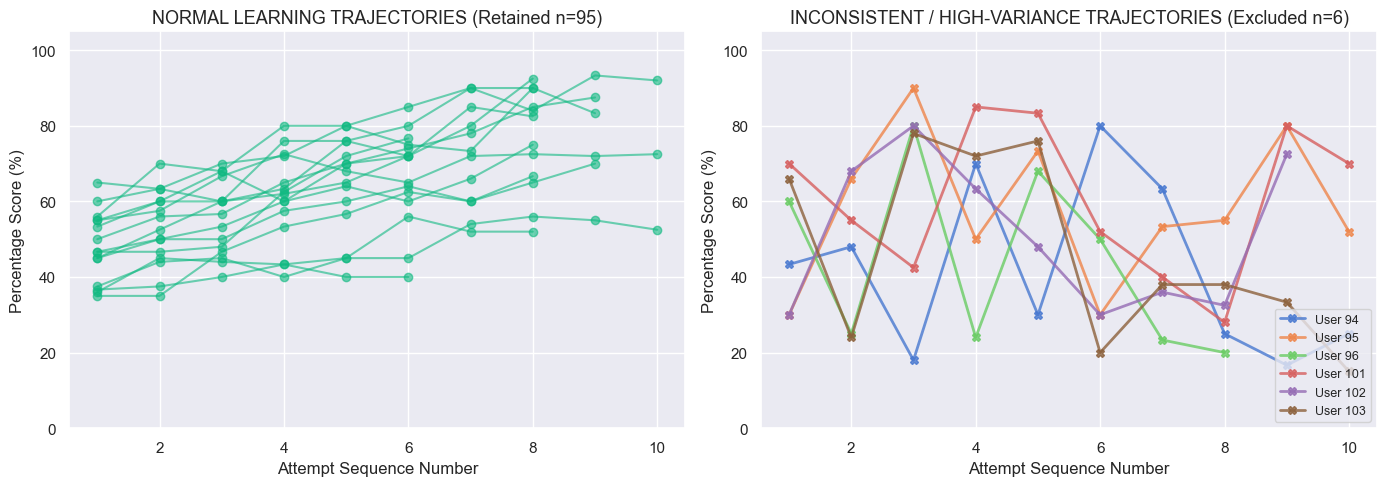

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

excluded_uids = summary_meta['excluded_user_ids']
df_clean = df_raw[~df_raw['user_id'].isin(excluded_uids)]
df_outliers = df_raw[df_raw['user_id'].isin(excluded_uids)]

# 1. Normal Learning Cohort Trajectories (Sample 15)
for uid in df_clean['user_id'].unique()[:15]:
    u_data = df_clean[df_clean['user_id'] == uid].sort_values('attempt_order_by_user')
    axes[0].plot(u_data['attempt_order_by_user'], u_data['percentage'], alpha=0.6, marker='o', color='#10b981')

axes[0].set_title(f'NORMAL LEARNING TRAJECTORIES (Retained n={len(df_clean["user_id"].unique())})')
axes[0].set_xlabel('Attempt Sequence Number')
axes[0].set_ylabel('Percentage Score (%)')
axes[0].set_ylim(0, 105)

# 2. High-Variance Outlier Trajectories
for uid in excluded_uids:
    u_data = df_outliers[df_outliers['user_id'] == uid].sort_values('attempt_order_by_user')
    axes[1].plot(u_data['attempt_order_by_user'], u_data['percentage'], alpha=0.8, marker='X', linewidth=2, label=f'User {uid}')

axes[1].set_title(f'INCONSISTENT / HIGH-VARIANCE TRAJECTORIES (Excluded n={len(excluded_uids)})')
axes[1].set_xlabel('Attempt Sequence Number')
axes[1].set_ylabel('Percentage Score (%)')
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


## 9. Summary & Pipeline Artifact Confirmation

### EDA Findings:
1. The new cohort consists of **101 learners** with 6–10 attempts each (**788 total attempts**).
2. **6 learners (Users 94, 95, 96, 101, 102, 103)** exhibit extreme score volatility (`std_score > 19.5%`, `avg_abs_delta > 18.6%`, 2–4 extreme score reversals $\ge 35\%$) with no directional progress (`attempt_score_corr <= 0.08`).
3. **95 clean learners** showing positive, realistic learning trajectories (`mean slope = +5.8%` per attempt, `mean correlation = +0.95`) are retained.
4. Processed datasets generated:
   - `ml/data/processed/clean_learner_dataset.csv` (731 attempts across 95 learners)
   - `ml/data/processed/excluded_learners.csv` (6 excluded learners with audit rationale)
   - `ml/reports/outlier_analysis.json` (Structured JSON audit report)
